In [3]:
import pandas as pd
from pycaret.regression import *

# Charger les données
data = pd.read_csv("C:\\Users\\user\\Desktop\\Project\\the_last_one.csv",sep=",")


# Vérifiez un aperçu des données
data.head(20)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Peer_Influence,Physical_Activity,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23.0,84.0,Low,High,0,7.0,14.6,Low,1,0.0,Low,Positive,3.0,High School,Near,0,13.4
1,19.0,64.0,Low,Medium,0,8.0,11.8,Low,1,2.0,Medium,Negative,4.0,College,Moderate,1,12.2
2,24.0,98.0,Medium,Medium,1,7.0,18.2,Medium,1,2.0,Medium,Neutral,4.0,Postgraduate,Near,0,14.8
3,29.0,89.0,Low,Medium,1,8.0,19.6,Medium,1,1.0,Medium,Negative,4.0,High School,Moderate,0,14.2
4,19.0,92.0,Medium,Medium,1,6.0,13.0,Medium,1,3.0,Medium,Neutral,4.0,College,Near,1,14.0
5,19.0,88.0,Medium,Medium,1,8.0,17.8,Medium,1,3.0,Medium,Positive,3.0,Postgraduate,Near,0,14.2
6,29.0,84.0,Medium,Low,1,7.0,13.6,Low,1,1.0,Low,Neutral,2.0,High School,Moderate,0,13.4
7,25.0,78.0,Low,High,1,6.0,10.0,Medium,1,1.0,High,Negative,2.0,High School,Far,0,13.2
8,17.0,94.0,Medium,High,0,6.0,16.0,High,1,0.0,Medium,Neutral,1.0,College,Near,0,13.8
9,23.0,98.0,Medium,Medium,1,8.0,14.2,Medium,1,0.0,High,Positive,5.0,High School,Moderate,0,14.4


In [5]:
print(data.info())  # Vérifiez les types de données et les valeurs manquantes
print(data.describe())  # Statistiques descriptives
print(data.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6617 entries, 0 to 6616
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Hours_Studied               6617 non-null   float64
 1   Attendance                  6617 non-null   float64
 2   Parental_Involvement        6617 non-null   object 
 3   Access_to_Resources         6617 non-null   object 
 4   Extracurricular_Activities  6617 non-null   int64  
 5   Sleep_Hours                 6617 non-null   float64
 6   Previous_Scores             6617 non-null   float64
 7   Motivation_Level            6617 non-null   object 
 8   Internet_Access             6617 non-null   int64  
 9   Tutoring_Sessions           6617 non-null   float64
 10  Family_Income               6617 non-null   object 
 11  Peer_Influence              6617 non-null   object 
 12  Physical_Activity           6617 non-null   float64
 13  Parental_Education_Level    6617 

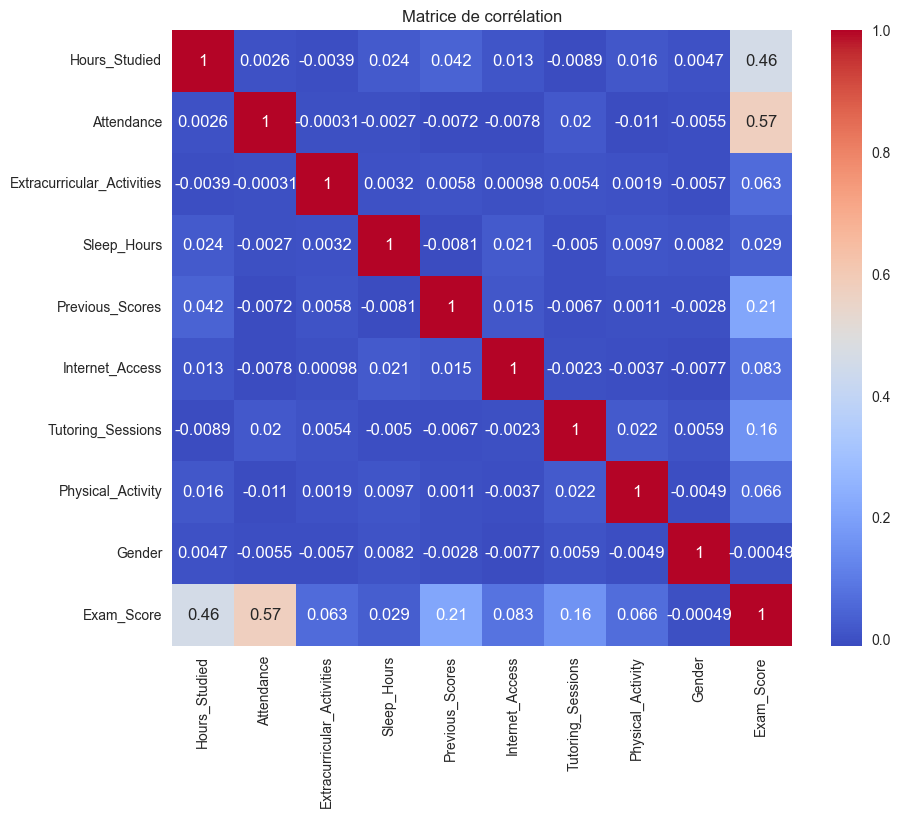

In [9]:
import matplotlib.pyplot as plt  # Ajoutez cette ligne
import seaborn as sns  # Si ce n'est pas déjà importé
# Sélectionner uniquement les colonnes numériques
data_numeric = data.select_dtypes(include=['float64', 'int64'])

# Calculer et afficher la matrice de corrélation
plt.figure(figsize=(10, 8))
sns.heatmap(data_numeric.corr(), annot=True, cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.show()

In [13]:
import pandas as pd
from pycaret.regression import *

In [15]:
from sklearn.preprocessing import LabelEncoder

# Liste des colonnes à encoder
categorical_columns = [
    'Parental_Involvement',
    'Access_to_Resources',
    'Motivation_Level',
    'Family_Income',
    'Peer_Influence',
    'Parental_Education_Level',
    'Distance_from_Home'
]

# Créer un encodeur
label_encoder = LabelEncoder()

# Encoder chaque colonne catégorique
for column in categorical_columns:
    data[column] = label_encoder.fit_transform(data[column])

In [17]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6617 entries, 0 to 6616
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Hours_Studied               6617 non-null   float64
 1   Attendance                  6617 non-null   float64
 2   Parental_Involvement        6617 non-null   int32  
 3   Access_to_Resources         6617 non-null   int32  
 4   Extracurricular_Activities  6617 non-null   int64  
 5   Sleep_Hours                 6617 non-null   float64
 6   Previous_Scores             6617 non-null   float64
 7   Motivation_Level            6617 non-null   int32  
 8   Internet_Access             6617 non-null   int64  
 9   Tutoring_Sessions           6617 non-null   float64
 10  Family_Income               6617 non-null   int32  
 11  Peer_Influence              6617 non-null   int32  
 12  Physical_Activity           6617 non-null   float64
 13  Parental_Education_Level    6617 

In [19]:
data.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Peer_Influence,Physical_Activity,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23.0,84.0,1,0,0,7.0,14.6,1,1,0.0,1,2,3.0,1,2,0,13.4
1,19.0,64.0,1,2,0,8.0,11.8,1,1,2.0,2,0,4.0,0,1,1,12.2
2,24.0,98.0,2,2,1,7.0,18.2,2,1,2.0,2,1,4.0,2,2,0,14.8
3,29.0,89.0,1,2,1,8.0,19.6,2,1,1.0,2,0,4.0,1,1,0,14.2
4,19.0,92.0,2,2,1,6.0,13.0,2,1,3.0,2,1,4.0,0,2,1,14.0


In [21]:
# Appliquer le setup
reg = setup(
    data=data,
    target='Exam_Score',  # Variable cible
    session_id=123,  # Pour des résultats reproductibles
    normalize=True,  # Normaliser les données pour les modèles sensibles à l'échelle
    remove_multicollinearity=True,  # Supprimer la multicolinéarité si détectée
    transformation=True  # Appliquer une transformation (log ou autre) si nécessaire
)

,Description,Value
0,Session id,123
1,Target,Exam_Score
2,Target type,Regression
3,Original data shape,"(6617, 17)"
4,Transformed data shape,"(6617, 17)"
5,Transformed train set shape,"(4631, 17)"
6,Transformed test set shape,"(1986, 17)"
7,Numeric features,16
8,Preprocess,True
9,Imputation type,simple


In [23]:
best_model = compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,0.1889,0.2002,0.4365,0.7196,0.0290,0.0139,0.1530
lightgbm,Light Gradient Boosting Machine,0.1941,0.2018,0.4390,0.7156,0.0288,0.0142,0.1120
et,Extra Trees Regressor,0.2311,0.2204,0.4611,0.6874,0.0302,0.0170,0.3910
rf,Random Forest Regressor,0.2448,0.2328,0.4738,0.6701,0.0312,0.0180,0.3990
huber,Huber Regressor,0.2369,0.2471,0.4882,0.6522,0.0340,0.0178,0.0490
lr,Linear Regression,0.2391,0.2472,0.4885,0.6515,0.0339,0.0179,0.6320
ridge,Ridge Regression,0.2391,0.2472,0.4885,0.6515,0.0339,0.0179,0.0520
lar,Least Angle Regression,0.2391,0.2472,0.4885,0.6515,0.0339,0.0179,0.0440
br,Bayesian Ridge,0.2390,0.2472,0.4885,0.6515,0.0339,0.0179,0.0440
knn,K Neighbors Regressor,0.3624,0.3398,0.5787,0.5123,0.0390,0.0268,0.0530


In [25]:
gbr_model = create_model('gbr')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.2183,0.3374,0.5809,0.5940,0.0386,0.0160
1,0.1824,0.1359,0.3686,0.8083,0.0256,0.0138
2,0.2110,0.2704,0.5200,0.5823,0.0335,0.0151
3,0.1811,0.1395,0.3735,0.7976,0.0267,0.0138
4,0.1780,0.1720,0.4147,0.7759,0.0259,0.0129
5,0.1700,0.1346,0.3669,0.7580,0.0233,0.0124
6,0.2210,0.3283,0.5730,0.6186,0.0383,0.0164
7,0.1923,0.2726,0.5221,0.6231,0.0326,0.0135
8,0.1577,0.0800,0.2828,0.8271,0.0188,0.0116


In [27]:
tuned_model = tune_model(gbr_model)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.2353,0.3412,0.5841,0.5894,0.0383,0.0172
1,0.2207,0.1657,0.4071,0.7663,0.0277,0.0165
2,0.2387,0.2768,0.5261,0.5725,0.0337,0.0171
3,0.2177,0.1692,0.4114,0.7545,0.0285,0.0164
4,0.2085,0.2021,0.4496,0.7367,0.0284,0.0152
5,0.1933,0.1623,0.4028,0.7082,0.0257,0.0140
6,0.2333,0.3163,0.5624,0.6325,0.0363,0.0170
7,0.2192,0.2962,0.5443,0.5904,0.0342,0.0155
8,0.1874,0.1078,0.3283,0.7670,0.0219,0.0139


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


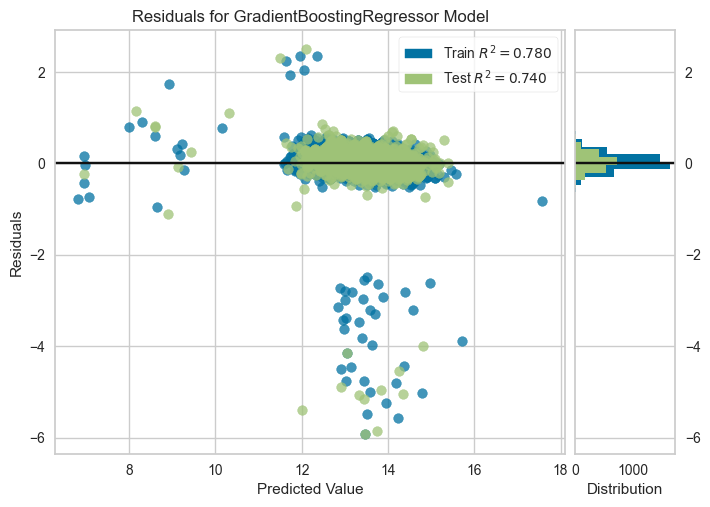

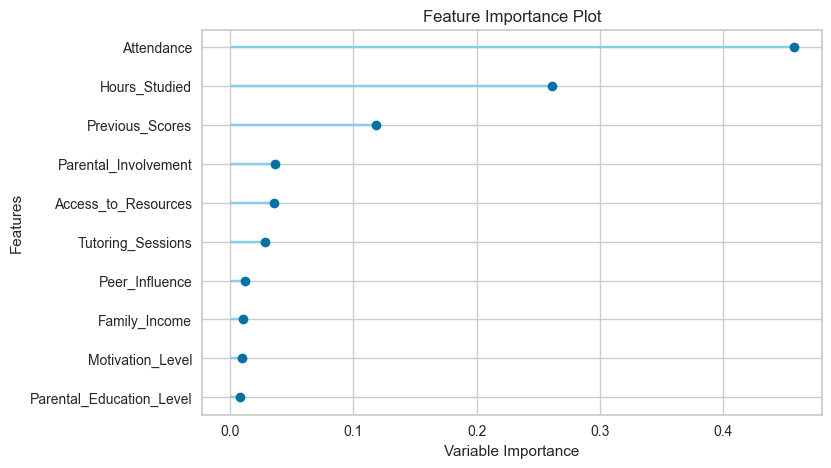

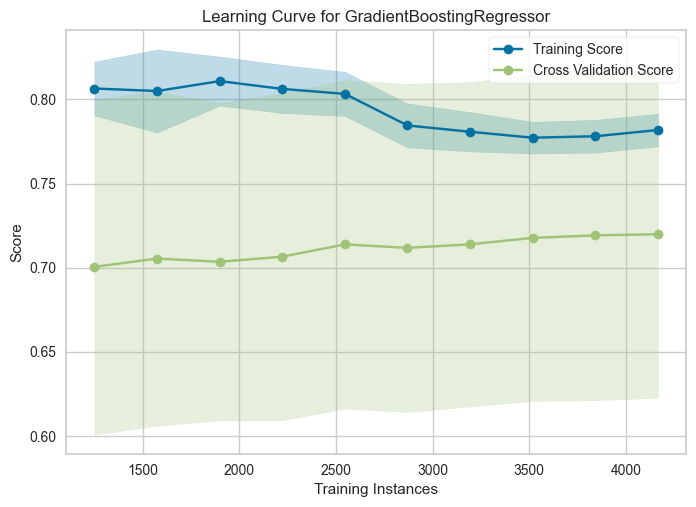

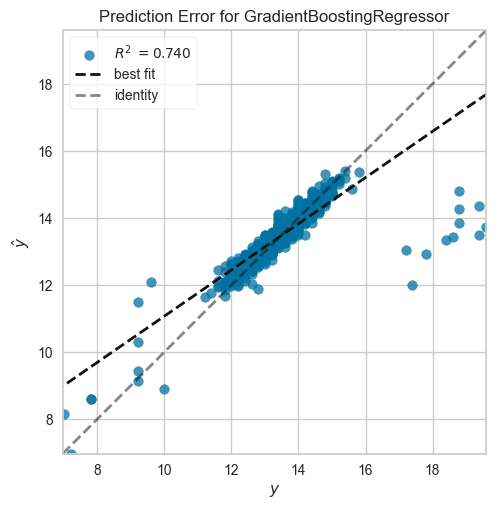

In [29]:
plot_model(tuned_model, plot='residuals')
plot_model(tuned_model, plot='feature')
plot_model(tuned_model, plot='learning')
plot_model(tuned_model, plot='error')

In [31]:
import pandas as pd

# Supposons que df soit votre DataFrame d'origine contenant les valeurs cibles
Q1 = data['Exam_Score'].quantile(0.25)
Q3 = data['Exam_Score'].quantile(0.75)
IQR = Q3 - Q1

# Filtrer les outliers
df_filtered = data[(data['Exam_Score'] >= (Q1 - 2.5 * IQR)) & (data['Exam_Score'] <= (Q3 + 2.5 * IQR))]

In [33]:
X = df_filtered.drop('Exam_Score', axis=1)

y = df_filtered['Exam_Score']

# Encoder les variables catégorielles
X_encoded = pd.get_dummies(X, drop_first=True)

# Division des données
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Normalisation
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [35]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

grid_search = GridSearchCV(GradientBoostingRegressor(), param_grid, cv=5)
grid_search.fit(X_train_scaled, y_train)

# Meilleur modèle
tuned_model = grid_search.best_estimator_

In [37]:
from sklearn.metrics import mean_squared_error, r2_score

predictions = tuned_model.predict(X_test_scaled)
rmse = mean_squared_error(y_test, predictions, squared=False)
r2 = r2_score(y_test, predictions)

print(f'RMSE: {rmse:.2f}, R²: {r2:.2f}')

RMSE: 0.15, R²: 0.95


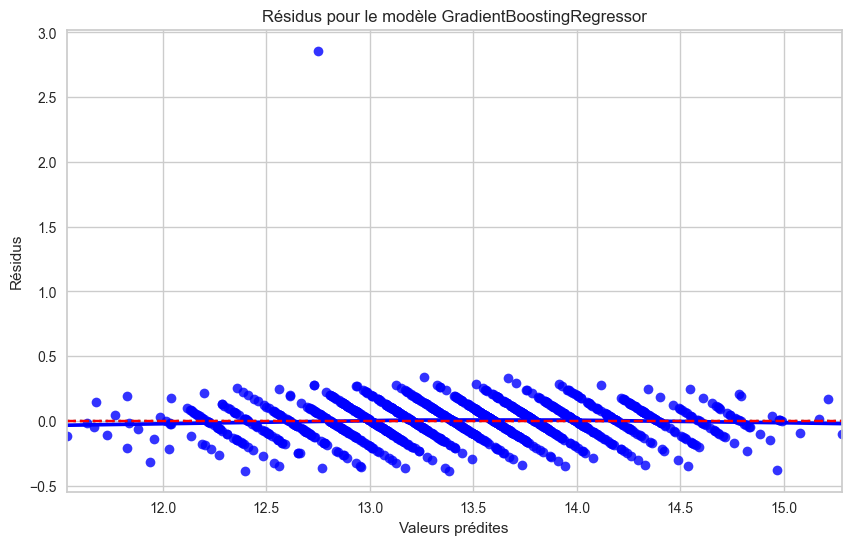

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.residplot(x=predictions, y=y_test - predictions, lowess=True, color='blue')
plt.axhline(0, linestyle='--', color='red')
plt.title('Résidus pour le modèle GradientBoostingRegressor')
plt.xlabel('Valeurs prédites')
plt.ylabel('Résidus')
plt.show()

In [43]:
predictions = predict_model(tuned_model, data = data)
predictions.head(30)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Gradient Boosting Regressor,0.1286,0.2009,0.4482,0.7120,0.0311,0.0097


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Peer_Influence,Physical_Activity,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,prediction_label
0,23.0,84.0,1,0,0,7.0,14.600000,1,1,0.0,1,2,3.0,1,2,0,13.4,13.422736
1,19.0,64.0,1,2,0,8.0,11.800000,1,1,2.0,2,0,4.0,0,1,1,12.2,12.267326
2,24.0,98.0,2,2,1,7.0,18.200001,2,1,2.0,2,1,4.0,2,2,0,14.8,14.835670
3,29.0,89.0,1,2,1,8.0,19.600000,2,1,1.0,2,0,4.0,1,1,0,14.2,14.098205
4,19.0,92.0,2,2,1,6.0,13.000000,2,1,3.0,2,1,4.0,0,2,1,14.0,14.060875
5,19.0,88.0,2,2,1,8.0,17.799999,2,1,3.0,2,2,3.0,2,2,0,14.2,14.288747
6,29.0,84.0,2,1,1,7.0,13.600000,1,1,1.0,1,1,2.0,1,1,0,13.4,13.511711
7,25.0,78.0,1,0,1,6.0,10.000000,2,1,1.0,0,0,2.0,1,0,0,13.2,13.139949
8,17.0,94.0,2,0,0,6.0,16.000000,0,1,0.0,2,1,1.0,0,2,0,13.8,13.928132
9,23.0,98.0,2,2,1,8.0,14.200000,2,1,0.0,0,2,5.0,1,1,0,14.4,14.327078


In [45]:
import pickle

# Sauvegarder le modèle
with open('last_modele.pkl', 'wb') as file:
    pickle.dump(tuned_model, file)